## Analysis of the results obtained from enrichment using the ViSEAGO package.

In [1]:
##load libraries
library(dplyr)
library(readxl)
library(plotly)
library(reshape2)
library(ggplot2)
library(svglite)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2


Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout


Warning message:
“package ‘svglite’ was built under R version 4.3.3”


In [2]:
files <- list.files(path = "./Viseago_Res", pattern = "BP_Results_.*\\.xls", full.names = TRUE)
conditions <- c('Glucose','LB','Glucosamine','Glycerol','Xylose','Mannose','Galactose','Fructose','Acetate','Pyruvate','Succinate')

data_list <- list()

for (i in 1:length(files)) {
  file <- files[i]
  condition <- conditions[i]
  data_file <- read.table(file, header = TRUE)

  data_file$Condition <- condition
  data_list[[condition]] <- data_file
 #print(condition)
}
final_data <- do.call(rbind, data_list)
head(final_data, 2)

,GO.ID,term,definition,Essential.genes_frequency,Essential.pvalue,Essential..log10_pvalue,Essential.Significant_genes,Essential.Significant_genes_symbol,Important.genes_frequency,Important.pvalue,⋯,No_effect.pvalue,No_effect..log10_pvalue,No_effect.Significant_genes,No_effect.Significant_genes_symbol,Fitness_enhancing.genes_frequency,Fitness_enhancing.pvalue,Fitness_enhancing..log10_pvalue,Fitness_enhancing.Significant_genes,Fitness_enhancing.Significant_genes_symbol,Condition
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Glucose.1,GO:0022411,cellular component disassembly,A cellular process that results in the breakdown of a cellular component.,28.571% (12/42),2.109099e-03,2.68,945779;946122;946225;947285;947369;947439;947793;947816;947818;947847;948485;949002,prmC;frr;infC;suhB;prfB;yqgF;rpsD;rpsJ;rplD;fusA;nusG;prfA,19.048% (8/42),0.1393531,⋯,1.0000000,0,NA,NA,0% (0/42),1,0,NA,NA,Glucose
Glucose.2,GO:0006633,fatty acid biosynthetic process,"The chemical reactions and pathways resulting in the formation of a fatty acid, any of the aliphatic monocarboxylic acids that can be liberated by hydrolysis from naturally occurring fats and oils. Fatty acids are predominantly straight-chain acids of 4 to 24 carbon atoms, which may be saturated or unsaturated; branched fatty acids and hydroxy fatty acids also occur, and very long chain acids of over 30 carbons are found in waxes.",50% (13/26),1.402913e-06,5.85,944805;944888;944895;945217;945568;945645;945766;945870;946796;946799;947037;947758;947761,acpP;fabZ;accA;lipB;fabA;fabG;fabD;fabI;accD;fabB;acpS;accB;accC,0% (0/26),1.0000000,⋯,0.9999865,0,NA,NA,0% (0/26),1,0,NA,NA,Glucose


In [3]:
#colnames(final_data)
selected_columns <- final_data[, c(1, 2, 6, 11, 16, 21, 24)]
colnames(selected_columns) <- c("GO", "term", "Essential", "Important", "No effect", "Enchancing", "Condition")
selected_columns <- selected_columns[selected_columns$Condition != "LB", ]

In [4]:
conditions <- unique(selected_columns$Condition)

# Filter the GO values that appear in all conditions.
common_GO <- selected_columns$GO[sapply(selected_columns$GO, function(go) {
  all(conditions %in% selected_columns$Condition[selected_columns$GO == go])
})]

all_conds <- selected_columns[selected_columns$GO %in% common_GO, ]
head(all_conds)

,GO,term,Essential,Important,No effect,Enchancing,Condition
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Glucose.2,GO:0006633,fatty acid biosynthetic process,5.85,0.00,0,0.0,Glucose
Glucose.4,GO:0033875,ribonucleoside bisphosphate metabolic process,3.20,0.42,0,0.0,Glucose
Glucose.5,GO:0044249,cellular biosynthetic process,6.34,0.08,0,0.2,Glucose
Glucose.7,GO:0009152,purine ribonucleotide biosynthetic process,6.43,0.35,0,0.0,Glucose
Glucose.8,GO:0009156,ribonucleoside monophosphate biosynthetic process,10.00,0.00,0,0.0,Glucose
Glucose.13,GO:0006553,lysine metabolic process,3.55,0.00,0,0.0,Glucose


In [5]:
uGOs_shar <- unique(all_conds$GO)
len_uGOs <- length(unique(all_conds$GO))
print(paste("There are", len_uGOs, "GOs shared across all conditions."))

[1] "There are 54 GOs shared across all conditions."


## There are 54 GOs shared across all conditions.
### To improve the visualization of the dotplot, the mean of all conditions was calculated for both the enrichment values and the frequencies.

In [6]:
#Select freqs columns
selected_columns2 <- final_data[, c(1, 2, 4, 9, 14, 19, 24)]
colnames(selected_columns2) <- c("GO", "term", "Essential", "Important", "No effect", "Enchancing", "Condition")
selected_columns2 <- selected_columns2[selected_columns2$Condition != "LB", ]

In [7]:
conditions_fr <- unique(selected_columns2$Condition)

# Filter the GO values that appear in all conditions
common_GO <- selected_columns2$GO[sapply(selected_columns2$GO, function(go) {
  all(conditions_fr %in% selected_columns2$Condition[selected_columns2$GO == go])
})]

all_conds2 <- selected_columns2[selected_columns2$GO %in% common_GO, ]
#all_conds2

In [8]:
extract_value <- function(value) {
  sub("%.*", "", value)
}
all_conds3 <- all_conds2
all_conds3[3:6] <- lapply(all_conds3[3:6], extract_value)
head(all_conds3)

,GO,term,Essential,Important,No effect,Enchancing,Condition
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Glucose.2,GO:0006633,fatty acid biosynthetic process,50,0,38.462,0,Glucose
Glucose.4,GO:0033875,ribonucleoside bisphosphate metabolic process,39.13,8.696,39.13,0,Glucose
Glucose.5,GO:0044249,cellular biosynthetic process,26.249,7.266,57.584,1.09,Glucose
Glucose.7,GO:0009152,purine ribonucleotide biosynthetic process,41.86,6.977,23.256,0,Glucose
Glucose.8,GO:0009156,ribonucleoside monophosphate biosynthetic process,62.069,0,27.586,0,Glucose
Glucose.13,GO:0006553,lysine metabolic process,42.857,0,47.619,0,Glucose


In [9]:
go <- all_conds[all_conds$GO == "GO:0006633", ]
go

,GO,term,Essential,Important,No effect,Enchancing,Condition
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Glucose.2,GO:0006633,fatty acid biosynthetic process,5.85,0.00,0,0.00,Glucose
Glucosamine.1,GO:0006633,fatty acid biosynthetic process,4.52,0.26,0,0.00,Glucosamine
Glycerol.1,GO:0006633,fatty acid biosynthetic process,5.30,0.35,0,0.86,Glycerol
Xylose.1,GO:0006633,fatty acid biosynthetic process,4.85,0.12,0,0.64,Xylose
Mannose.1,GO:0006633,fatty acid biosynthetic process,4.82,0.67,0,0.53,Mannose
Galactose.24,GO:0006633,fatty acid biosynthetic process,6.87,0.00,0,1.08,Galactose
Fructose.2,GO:0006633,fatty acid biosynthetic process,4.97,0.05,0,0.22,Fructose
Acetate.1,GO:0006633,fatty acid biosynthetic process,5.30,0.00,0,0.30,Acetate
Pyruvate.1,GO:0006633,fatty acid biosynthetic process,5.37,0.00,0,0.79,Pyruvate


In [10]:
sel_col2 <- all_conds[, c(2, 3, 4, 5, 7)]

# Calculate the average of the numeric columns. 
pvals_means <- sel_col2 %>%
  group_by(term) %>%
  summarise(across(c(Essential, Important, `No effect`), mean, na.rm = TRUE))

head(pvals_means)

Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `across(c(Essential, Important, `No effect`), mean, na.rm =
  TRUE)`.
ℹ In group 1: `term = "DNA replication"`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


term,Essential,Important,No effect
<chr>,<dbl>,<dbl>,<dbl>
DNA replication,3.066,0.225,0.000
DNA-templated DNA replication,3.008,0.381,0.000
alpha-amino acid biosynthetic process,4.788,1.855,0.000
amino acid biosynthetic process,7.318,1.185,0.000
amino acid transport,0.000,0.004,5.089
anaerobic respiration,0.000,0.037,4.223


In [11]:
# Normalize the values of the numeric columns.

normalize <- function(x) {
  return ((x - min(x)) / (max(x) - min(x)) * 10)
}

normalized_pval <- pvals_means %>%
  mutate(across(c(Essential, Important, `No effect`), normalize))
head(normalized_pval)

term,Essential,Important,No effect
<chr>,<dbl>,<dbl>,<dbl>
DNA replication,1.509750,0.73601570,0.000000
DNA-templated DNA replication,1.481190,1.24631992,0.000000
alpha-amino acid biosynthetic process,2.357692,6.06804056,0.000000
amino acid biosynthetic process,3.603506,3.87634936,0.000000
amino acid transport,0.000000,0.01308472,6.187234
anaerobic respiration,0.000000,0.12103369,5.134347


In [12]:
melted_pval <- melt(normalized_pval, id.vars = c("term"), 
                    measure.vars = c("Essential", "Important", "No effect"))
head(melted_pval)

,term,variable,value
,<chr>,<fct>,<dbl>
1,DNA replication,Essential,1.509750
2,DNA-templated DNA replication,Essential,1.481190
3,alpha-amino acid biosynthetic process,Essential,2.357692
4,amino acid biosynthetic process,Essential,3.603506
5,amino acid transport,Essential,0.000000
6,anaerobic respiration,Essential,0.000000


In [13]:
head(all_conds3, 2)

,GO,term,Essential,Important,No effect,Enchancing,Condition
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Glucose.2,GO:0006633,fatty acid biosynthetic process,50,0,38.462,0,Glucose
Glucose.4,GO:0033875,ribonucleoside bisphosphate metabolic process,39.13,8.696,39.13,0,Glucose


In [14]:
sel_col4 <- all_conds3[, c(2, 3, 4, 5, 7)]
sel_col4 <- sel_col4 %>%
  mutate(across(c(Essential, Important, `No effect`), as.numeric))

# calcular promedio de las columnas numéricas
freqs_means <- sel_col4 %>%
  group_by(term) %>%
  summarise(across(c(Essential, Important, `No effect`), mean, na.rm = TRUE))

head(freqs_means)

term,Essential,Important,No effect
<chr>,<dbl>,<dbl>,<dbl>
DNA replication,33.7498,5.9375,50.0000
DNA-templated DNA replication,31.2500,7.7500,50.7500
alpha-amino acid biosynthetic process,41.7648,12.2689,38.8235
amino acid biosynthetic process,44.4682,11.8440,36.8084
amino acid transport,1.0100,1.4140,95.2526
anaerobic respiration,3.1147,2.6230,93.1148


In [15]:
#normalize cols
normalize <- function(x) {
  return ((x - min(x)) / (max(x) - min(x)))
}

normalized_data2 <- freqs_means %>%
  mutate(across(c(Essential, Important, `No effect`), normalize))
head(normalized_data2)


term,Essential,Important,No effect
<chr>,<dbl>,<dbl>,<dbl>
DNA replication,0.42187250,0.28500182,0.4531240
DNA-templated DNA replication,0.39062500,0.37200238,0.4613271
alpha-amino acid biosynthetic process,0.52206000,0.58891097,0.3308808
amino acid biosynthetic process,0.55585250,0.56851564,0.3088406
amino acid transport,0.01262500,0.06787243,0.9480752
anaerobic respiration,0.03893375,0.12590481,0.9246930


In [16]:
melted_freqs <- melt(normalized_data2, id.vars = c("term"), 
                    measure.vars = c("Essential", "Important", "No effect"))
head(melted_freqs)

,term,variable,value
,<chr>,<fct>,<dbl>
1,DNA replication,Essential,0.42187250
2,DNA-templated DNA replication,Essential,0.39062500
3,alpha-amino acid biosynthetic process,Essential,0.52206000
4,amino acid biosynthetic process,Essential,0.55585250
5,amino acid transport,Essential,0.01262500
6,anaerobic respiration,Essential,0.03893375


In [17]:
#merge 
freq <- melted_freqs[, 3]
melted_pval$freq <- freq
head(melted_pval)

,term,variable,value,freq
,<chr>,<fct>,<dbl>,<dbl>
1,DNA replication,Essential,1.509750,0.42187250
2,DNA-templated DNA replication,Essential,1.481190,0.39062500
3,alpha-amino acid biosynthetic process,Essential,2.357692,0.52206000
4,amino acid biosynthetic process,Essential,3.603506,0.55585250
5,amino acid transport,Essential,0.000000,0.01262500
6,anaerobic respiration,Essential,0.000000,0.03893375


In [18]:
str(melted_pval)

'data.frame':	162 obs. of  4 variables:
 $ term    : chr  "DNA replication" "DNA-templated DNA replication" "alpha-amino acid biosynthetic process" "amino acid biosynthetic process" ...
 $ variable: Factor w/ 3 levels "Essential","Important",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ value   : num  1.51 1.48 2.36 3.6 0 ...
 $ freq    : num  0.4219 0.3906 0.5221 0.5559 0.0126 ...


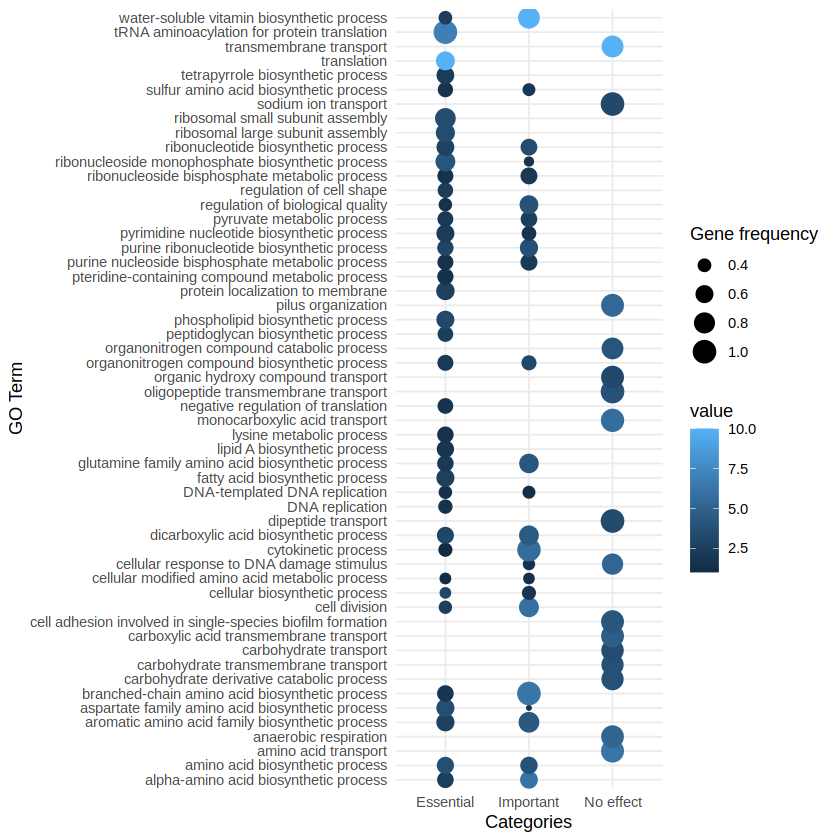

In [19]:
#remove dots with zero 
melted_pval %>% 
  filter(value > 1, freq > 0.25) %>% 
  ggplot(aes(x=variable, y = term, color = value, size = freq)) + 
  geom_point() +
  labs(x = "Categories", y = "GO Term", size = "Gene frequency") +
  theme_minimal()

### Figure 03. Dot plot of enriched Gene Ontology (GO) terms among the categories defined by fitness values 

### and present across all different carbon sources.

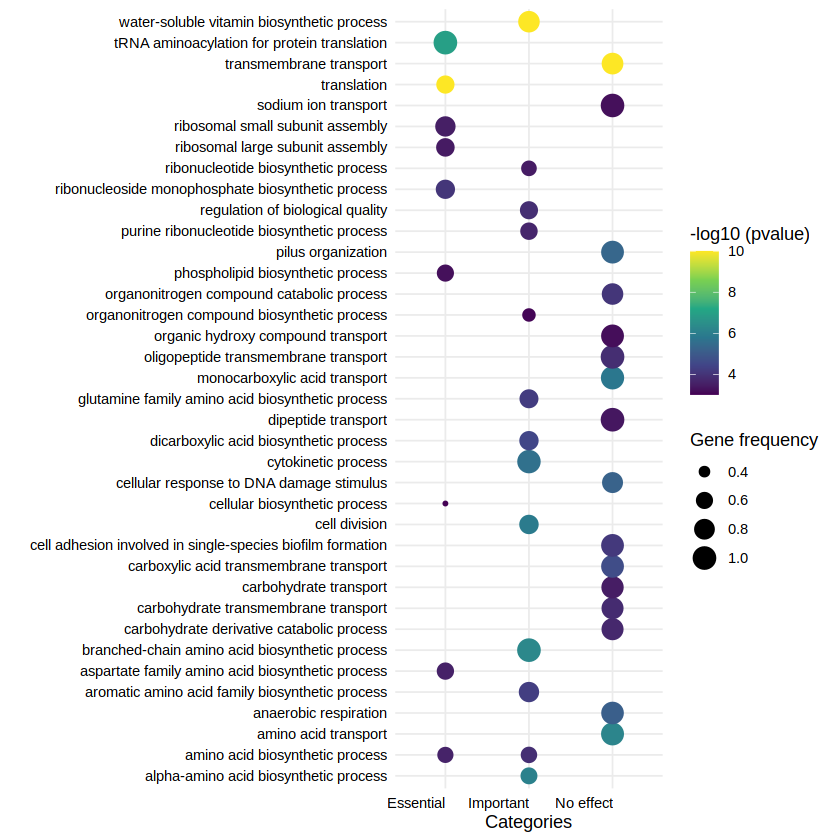

In [20]:
melted_pval %>% 
  filter(value > 3, freq > 0.25) %>% 
  ggplot(aes(x=variable, y = term, color = value, size = freq)) + 
  geom_point() +
  labs(x = "Categories", y = "GO Term", size = "Gene frequency") +
  theme_minimal() +
  scale_color_viridis_c(name = '-log10 (pvalue)') + 
  theme(axis.line  = element_blank()) +
  theme(axis.text.x = element_text(vjust = 0.5, hjust=1, colour = "black")) +   #angle = 90
  theme(axis.text.y = element_text(colour = "black")) +
  ylab('') +
  theme(axis.ticks = element_blank())

In [21]:
p <- melted_pval %>% 
  filter(value > 3, freq > 0.25) %>% 
  ggplot(aes(x=variable, y = term, color = value, size = freq)) + 
  geom_point() +
  labs(x = "Categories", y = "GO Term", size = "Gene frequency") +
  theme_minimal() +
  scale_color_viridis_c(name = '-log10 (pvalue)') + 
  theme(axis.line  = element_blank()) +
  theme(axis.text.x = element_text(vjust = 0.5, hjust=1, colour = "black")) + 
  theme(axis.text.y = element_text(colour = "black")) +
  ylab('') +
  theme(axis.ticks = element_blank()) 
ggsave("./Figures/Fig03_dotplot_54GOs_10conds.png", p, width = 8, height = 8)

# save dotplot in SVG format.
#ggsave("./Figures/Fig03_dotplot_54GOs_10conds.svg", plot = p, width = 8, height = 8, units = "in", dpi = 300)

## Overview of all Gene Ontology (GO) processes.

In [22]:
dim(selected_columns2)

[1] 1125    7

In [23]:
#load data
files <- list.files(path = "./Viseago_Res", pattern = "BP_Results_.*\\.xls", full.names = TRUE)
conditions <- c('Glucose','LB','Glucosamine','Glycerol','Xylose','Mannose','Galactose','Fructose','Acetate','Pyruvate','Succinate')

data_list <- list()

for (i in 1:length(files)) {
  file <- files[i]
  condition <- conditions[i]
  data_file <- read.table(file, header = TRUE)

  data_file$Condition <- condition
  data_list[[condition]] <- data_file
 #print(condition)
}
final_data <- do.call(rbind, data_list)
head(final_data, 1)

,GO.ID,term,definition,Essential.genes_frequency,Essential.pvalue,Essential..log10_pvalue,Essential.Significant_genes,Essential.Significant_genes_symbol,Important.genes_frequency,Important.pvalue,⋯,No_effect.pvalue,No_effect..log10_pvalue,No_effect.Significant_genes,No_effect.Significant_genes_symbol,Fitness_enhancing.genes_frequency,Fitness_enhancing.pvalue,Fitness_enhancing..log10_pvalue,Fitness_enhancing.Significant_genes,Fitness_enhancing.Significant_genes_symbol,Condition
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Glucose.1,GO:0022411,cellular component disassembly,A cellular process that results in the breakdown of a cellular component.,28.571% (12/42),0.002109099,2.68,945779;946122;946225;947285;947369;947439;947793;947816;947818;947847;948485;949002,prmC;frr;infC;suhB;prfB;yqgF;rpsD;rpsJ;rplD;fusA;nusG;prfA,19.048% (8/42),0.1393531,⋯,1,0,NA,NA,0% (0/42),1,0,NA,NA,Glucose


In [24]:
#colnames(final_data)
selected_columns <- final_data[, c(1, 2, 6, 11, 16, 21, 24)]
colnames(selected_columns) <- c("GO", "term", "Essential", "Important", "No effect", "Enchancing", "Condition")
selected_columns <- selected_columns[selected_columns$Condition != "LB", ]

In [25]:
dim(selected_columns)
head(selected_columns)

[1] 1125    7

,GO,term,Essential,Important,No effect,Enchancing,Condition
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Glucose.1,GO:0022411,cellular component disassembly,2.68,0.86,0.00,0.00,Glucose
Glucose.2,GO:0006633,fatty acid biosynthetic process,5.85,0.00,0.00,0.00,Glucose
Glucose.3,GO:0072525,pyridine-containing compound biosynthetic process,2.51,0.86,0.00,0.00,Glucose
Glucose.4,GO:0033875,ribonucleoside bisphosphate metabolic process,3.20,0.42,0.00,0.00,Glucose
Glucose.5,GO:0044249,cellular biosynthetic process,6.34,0.08,0.00,0.20,Glucose
Glucose.6,GO:0045229,external encapsulating structure organization,2.22,0.01,0.15,0.32,Glucose


In [26]:
GOs <- unique(selected_columns$GO)
len_uGOs <- length(unique(selected_columns$GO))
print(paste("There are", len_uGOs, "GOs in all conditions"))

[1] "There are 239 GOs in all conditions"


## There are 239 GOs in all conditions
### First, the 54 gene ontology (GO) terms that are common across all conditions should be filtered. 


In [27]:
gos_shar <- list(uGOs_shar)
gos_shar

[[1]]
 [1] "GO:0006633" "GO:0033875" "GO:0044249" "GO:0009152" "GO:0009156"
 [6] "GO:0006553" "GO:0006575" "GO:0034032" "GO:0006090" "GO:0072657"
[11] "GO:0042364" "GO:0009067" "GO:0051301" "GO:0009082" "GO:0009084"
[16] "GO:0000097" "GO:0009073" "GO:0043650" "GO:0009260" "GO:0008652"
[21] "GO:0008654" "GO:0009252" "GO:0042558" "GO:0006260" "GO:0006261"
[26] "GO:1901607" "GO:0000027" "GO:0000028" "GO:0017148" "GO:0006412"
[31] "GO:0006418" "GO:0006221" "GO:0009245" "GO:1901566" "GO:0065008"
[36] "GO:0033014" "GO:0008360" "GO:0032506" "GO:0009061" "GO:0015718"
[41] "GO:0043711" "GO:1905039" "GO:0055085" "GO:0043709" "GO:0035672"
[46] "GO:1901136" "GO:0015850" "GO:0006865" "GO:0008643" "GO:0006814"
[51] "GO:0034219" "GO:0006974" "GO:0042938" "GO:1901565"

In [28]:
gos_shar <- unlist(strsplit(gsub("'", "", uGOs_shar), " "))
class(selected_columns) #1125 rows
filtered_df <- selected_columns %>%
  filter(!GO %in% gos_shar)
head(filtered_df)

[1] "data.frame"

,GO,term,Essential,Important,No effect,Enchancing,Condition
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Glucose.1,GO:0022411,cellular component disassembly,2.68,0.86,0.00,0.00,Glucose
Glucose.3,GO:0072525,pyridine-containing compound biosynthetic process,2.51,0.86,0.00,0.00,Glucose
Glucose.6,GO:0045229,external encapsulating structure organization,2.22,0.01,0.15,0.32,Glucose
Glucose.9,GO:0015949,nucleobase-containing small molecule interconversion,2.51,0.13,0.00,0.00,Glucose
Glucose.10,GO:0009185,ribonucleoside diphosphate metabolic process,2.83,0.42,0.00,0.00,Glucose
Glucose.11,GO:0022402,cell cycle process,2.87,0.70,0.00,0.44,Glucose


### Then, the average value of each GO across the different carbon source conditions will be calculated. This involves obtaining the average of all enrichment values, determined by the negative logarithm of the p-value, across the various conditions.

In [29]:
#normalize cols
normalize <- function(x) {
  return ((x - min(x)) / (max(x) - min(x)) * 10)
}

normalized_pval <- filtered_df %>%
  mutate(across(c(Essential, Important, `No effect`, Enchancing), normalize))
head(normalized_pval)

,GO,term,Essential,Important,No effect,Enchancing,Condition
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Glucose.1,GO:0022411,cellular component disassembly,5.403226,1.09414758,0.0000000,0.0000000,Glucose
Glucose.3,GO:0072525,pyridine-containing compound biosynthetic process,5.060484,1.09414758,0.0000000,0.0000000,Glucose
Glucose.6,GO:0045229,external encapsulating structure organization,4.475806,0.01272265,0.3080082,0.7079646,Glucose
Glucose.9,GO:0015949,nucleobase-containing small molecule interconversion,5.060484,0.16539440,0.0000000,0.0000000,Glucose
Glucose.10,GO:0009185,ribonucleoside diphosphate metabolic process,5.705645,0.53435115,0.0000000,0.0000000,Glucose
Glucose.11,GO:0022402,cell cycle process,5.786290,0.89058524,0.0000000,0.9734513,Glucose


In [30]:
melted_pval <- melt(normalized_pval, id.vars = c("term", "Condition"), 
                    measure.vars = c("Essential", "Important", "No effect", "Enchancing"))
head(melted_pval)

,term,Condition,variable,value
,<chr>,<chr>,<fct>,<dbl>
1,cellular component disassembly,Glucose,Essential,5.403226
2,pyridine-containing compound biosynthetic process,Glucose,Essential,5.060484
3,external encapsulating structure organization,Glucose,Essential,4.475806
4,nucleobase-containing small molecule interconversion,Glucose,Essential,5.060484
5,ribonucleoside diphosphate metabolic process,Glucose,Essential,5.705645
6,cell cycle process,Glucose,Essential,5.786290


In [31]:
fil_pval <- melted_pval %>%
  filter(value > 6)
head(fil_pval)   #570

,term,Condition,variable,value
,<chr>,<chr>,<fct>,<dbl>
1,glutamine family amino acid metabolic process,Glucose,Essential,6.108871
2,serine family amino acid biosynthetic process,Glucose,Essential,8.810484
3,sulfur compound biosynthetic process,Glucose,Essential,8.225806
4,serine family amino acid biosynthetic process,Glucosamine,Essential,7.963710
5,sulfur compound biosynthetic process,Glucosamine,Essential,6.068548
6,cell cycle process,Glycerol,Essential,6.451613


In [32]:
dim(melted_pval)
dim(fil_pval)

[1] 2340    4

[1] 108   4

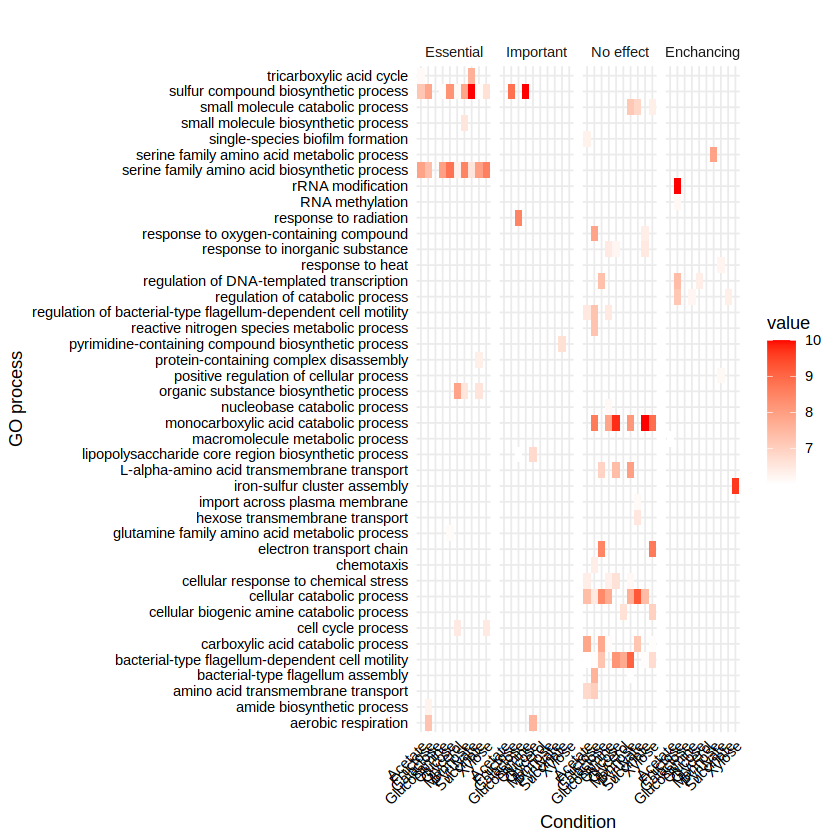

In [33]:
heatmap_plot <- ggplot(fil_pval, aes(x = Condition, y = term, fill = value)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "red") +
  theme_minimal() +
  labs(title = "",
       x = "Condition",
       y = "GO process") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, colour = "black")) +
  theme(axis.text.y = element_text(colour = "black")) +
  facet_wrap(~ variable, ncol = 4)

print(heatmap_plot)
ggsave("./Figures/heatm_32GOterm_enriched.png", plot = heatmap_plot, width = 10, height = 10, units = "in")


In [34]:
fil_pval2 <- melted_pval %>%
  filter(value > 5)  #5=219  6=96
head(fil_pval)
dim(fil_pval2)

,term,Condition,variable,value
,<chr>,<chr>,<fct>,<dbl>
1,glutamine family amino acid metabolic process,Glucose,Essential,6.108871
2,serine family amino acid biosynthetic process,Glucose,Essential,8.810484
3,sulfur compound biosynthetic process,Glucose,Essential,8.225806
4,serine family amino acid biosynthetic process,Glucosamine,Essential,7.963710
5,sulfur compound biosynthetic process,Glucosamine,Essential,6.068548
6,cell cycle process,Glycerol,Essential,6.451613


[1] 244   4

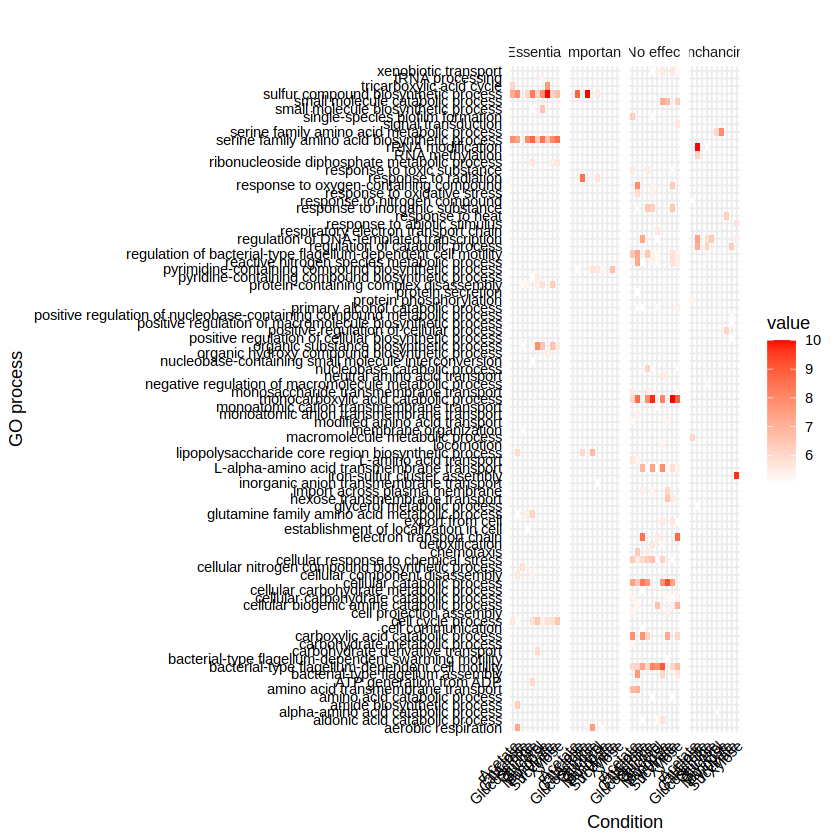

In [35]:
heatmap_plot <- ggplot(fil_pval2, aes(x = Condition, y = term, fill = value)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "red") +
  theme_minimal() +
  labs(title = "",
       x = "Condition",
       y = "GO process") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, colour = "black")) +
  theme(axis.text.y = element_text(colour = "black")) +
  facet_wrap(~ variable, ncol = 4)

print(heatmap_plot)
ggsave("./Figures/heatm_70GOterm_enrichp5.png", plot = heatmap_plot, width = 10, height = 12, units = "in")

In [36]:
melted_pval2 <- melt(normalized_pval, id.vars = c("term", "Condition"), 
                    measure.vars = c("Essential", "Important", "No effect", "Enchancing"))
head(melted_pval2)

,term,Condition,variable,value
,<chr>,<chr>,<fct>,<dbl>
1,cellular component disassembly,Glucose,Essential,5.403226
2,pyridine-containing compound biosynthetic process,Glucose,Essential,5.060484
3,external encapsulating structure organization,Glucose,Essential,4.475806
4,nucleobase-containing small molecule interconversion,Glucose,Essential,5.060484
5,ribonucleoside diphosphate metabolic process,Glucose,Essential,5.705645
6,cell cycle process,Glucose,Essential,5.786290


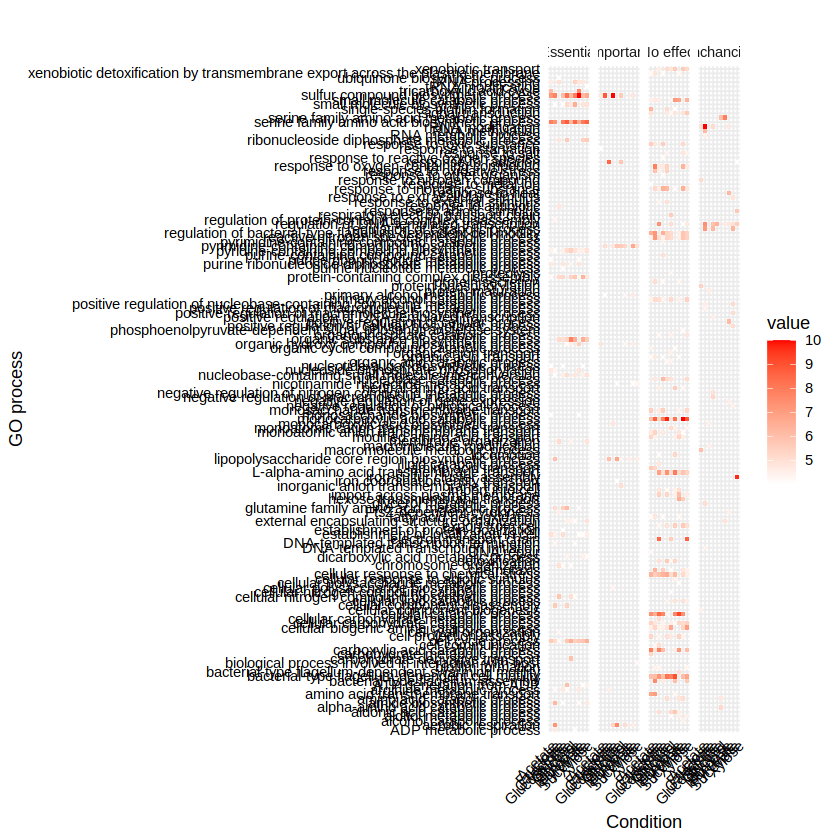

In [37]:
# Filter data 
fil_pval <- melted_pval2 %>%
  filter(value > 4)

heatmap_plot <- ggplot(fil_pval, aes(x = Condition, y = term, fill = value)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "red") +
  theme_minimal() +
  labs(title = "",
       x = "Condition",
       y = "GO process") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, colour = "black")) +
  theme(axis.text.y = element_text(colour = "black")) +
  facet_wrap(~ variable, ncol = 4)

print(heatmap_plot)
#ggsave("./Figures/heatm_allGOterms4.png", plot = heatmap_plot, width = 15, height = 20, units = "in")